In [8]:
import pandas as pd

neg_df = pd.read_excel("凑数的负样本.xlsx")
all_df = pd.read_excel("实验分泌蛋白正负样本.xlsx")


neg_df["label"] = 0
neg_df["source"] = "neg_sample"
all_df["source"] = "labeled_sample"


combined_df = pd.concat([neg_df, all_df], ignore_index=True)
combined_df = combined_df[["Entry", "Sequence", "label", "source"]]

combined_df = combined_df.dropna(subset=["Entry", "Sequence"])
combined_df = combined_df.drop_duplicates(subset=["Entry", "Sequence"])

fasta_path = "all_sequences.fasta"

with open(fasta_path, "w") as f:
    for _, row in combined_df.iterrows():
        f.write(f">{row['Entry']}\n{row['Sequence']}\n")

mapping_path = "sequence_metadata.csv"
combined_df.to_csv(mapping_path, index=False)

fasta_path, mapping_path


('all_sequences.fasta', 'sequence_metadata.csv')

In [18]:

!pip install -q condacolab
import condacolab
condacolab.install()


⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:14
🔁 Restarting kernel...


In [1]:
!mamba install -c bioconda mmseqs2 -y


Looking for: ['mmseqs2']

[+] 0.0s
bioconda/linux-64 ..  ⣾  [+] 0.1s
bioconda/linux-64 ..  ⣾  bioconda/linux-64 (check zst)                     
[+] 0.0s
bioconda/noarch (c..  ⣾  bioconda/noarch (check zst)                       
[+] 0.0s
conda-forge/linux-64  ⣾  
conda-forge/noarch    ⣾  
bioconda/linux-64     ⣾  
bioconda/noarch       ⣾  [+] 0.1s
conda-forge/linux-64  ⣾  
conda-forge/noarch    ⣾  
bioconda/linux-64      2%
bioconda/noarch        4%[+] 0.2s
conda-forge/linux-64  ⣾  
conda-forge/noarch     4%
bioconda/linux-64     43%
bioconda/noarch       53%[+] 0.3s
conda-forge/linux-64   2%
conda-forge/noarch    14%
bioconda/linux-64     82%
bioconda/noarch       94%bioconda/noarch                                   
[+] 0.4s
conda-forge/linux-64   4%
conda-forge/noarch    17%
bioconda/linux-64     93%bioconda/linux-64                                 
[+] 0.5s
conda-forge/linux-64   8%
conda-forge/noarch    26%[+] 0.6s
conda-forge/linux-64  10%
conda-forge/noarch    31%[+] 0.7s
cond

In [3]:
!mmseqs createdb all_sequences.fasta all_db


createdb all_sequences.fasta all_db 

MMseqs Version:       	17.b804f
Database type         	0
Shuffle input database	true
Createdb mode         	0
Write lookup file     	1
Offset of numeric ids 	0
Compressed            	0
Verbosity             	3

Converting sequences
[13737] 0s 20ms
Time for merging to all_db_h: 0h 0m 0s 4ms
Time for merging to all_db: 0h 0m 0s 5ms
Database type: Aminoacid
Time for processing: 0h 0m 0s 49ms


In [4]:
!mmseqs cluster all_db clustered_db tmp --min-seq-id 0.9 -c 0.8


Create directory tmp
cluster all_db clustered_db tmp --min-seq-id 0.9 -c 0.8 

MMseqs Version:                     	17.b804f
Substitution matrix                 	aa:blosum62.out,nucl:nucleotide.out
Seed substitution matrix            	aa:VTML80.out,nucl:nucleotide.out
Sensitivity                         	4
k-mer length                        	0
Target search mode                  	0
k-score                             	seq:2147483647,prof:2147483647
Alphabet size                       	aa:21,nucl:5
Max sequence length                 	65535
Max results per query               	20
Split database                      	0
Split mode                          	2
Split memory limit                  	0
Coverage threshold                  	0.8
Coverage mode                       	0
Compositional bias                  	1
Compositional bias                  	1
Diagonal scoring                    	true
Exact k-mer matching                	0
Mask residues                       	1
Mask residues prob

In [5]:
!mmseqs createsubdb clustered_db all_db rep_db
!mmseqs convert2fasta rep_db rep_sequences.fasta


createsubdb clustered_db all_db rep_db 

MMseqs Version: 	17.b804f
Subdb mode      	0
Database ID mode	0
Verbosity       	3

Time for merging to rep_db: 0h 0m 0s 0ms
Time for processing: 0h 0m 0s 5ms
convert2fasta rep_db rep_sequences.fasta 

MMseqs Version:	17.b804f
Use header DB	false
Verbosity    	3

Start writing file to rep_sequences.fasta
Time for processing: 0h 0m 0s 5ms


In [6]:
!mmseqs createtsv all_db all_db clustered_db clusters.tsv


createtsv all_db all_db clustered_db clusters.tsv 

MMseqs Version:                 	17.b804f
First sequence as representative	false
Target column                   	1
Add full header                 	false
Sequence source                 	0
Database output                 	false
Threads                         	2
Compressed                      	0
Verbosity                       	3

Time for merging to clusters.tsv: 0h 0m 0s 2ms
Time for processing: 0h 0m 0s 15ms


In [7]:
import pandas as pd

rep_ids = []
with open("rep_sequences.fasta") as f:
    for line in f:
        if line.startswith(">"):
            rep_ids.append(line.strip().replace(">", ""))

meta_df = pd.read_csv("sequence_metadata.csv")

filtered_df = meta_df[meta_df["Entry"].isin(rep_ids)]

filtered_df.to_csv("final_deduplicated_dataset.csv", index=False)



✅ 已保存去冗余后的数据表：final_deduplicated_dataset.csv


<ipython-input-8-e29fdf920110>:30: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-8-e29fdf920110>:30: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-8-e29fdf920110>:30: UserWarning: Glyph 21435 (\N{CJK UNIFIED IDEOGRAPH-53BB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-8-e29fdf920110>:30: UserWarning: Glyph 20887 (\N{CJK UNIFIED IDEOGRAPH-5197}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-8-e29fdf920110>:30: UserWarning: Glyph 20313 (\N{CJK UNIFIED IDEOGRAPH-4F59}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-8-e29fdf920110>:30: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-8-e29fdf920110>:30: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s

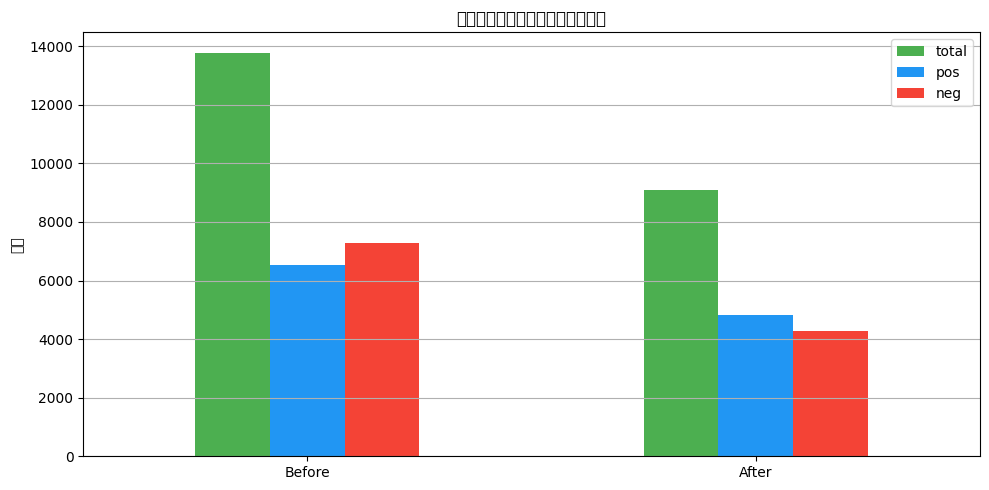

<ipython-input-8-e29fdf920110>:39: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-8-e29fdf920110>:39: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-8-e29fdf920110>:39: UserWarning: Glyph 21435 (\N{CJK UNIFIED IDEOGRAPH-53BB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-8-e29fdf920110>:39: UserWarning: Glyph 20887 (\N{CJK UNIFIED IDEOGRAPH-5197}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-8-e29fdf920110>:39: UserWarning: Glyph 20313 (\N{CJK UNIFIED IDEOGRAPH-4F59}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-8-e29fdf920110>:39: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-8-e29fdf920110>:39: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s

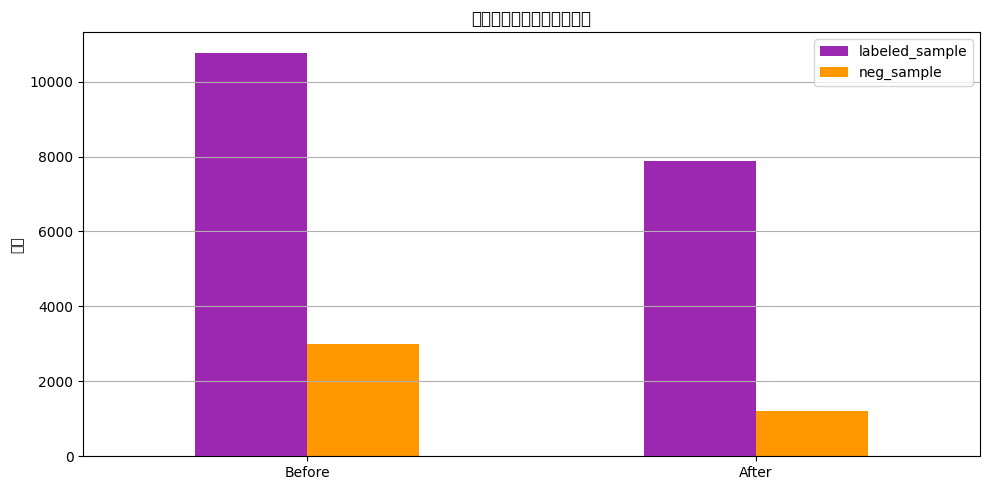

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# 加载两个数据集
df_before = pd.read_csv("sequence_metadata.csv")
df_after = pd.read_csv("final_deduplicated_dataset.csv")

# 统计函数
def get_stats(df, label):
    return {
        "total": len(df),
        "pos": (df["label"] == 1).sum(),
        "neg": (df["label"] == 0).sum(),
        "labeled_sample": (df["source"] == "labeled_sample").sum(),
        "neg_sample": (df["source"] == "neg_sample").sum()
    }

stats_before = get_stats(df_before, "Before")
stats_after = get_stats(df_after, "After")

# 构建 DataFrame 用于画图
summary_df = pd.DataFrame([stats_before, stats_after], index=["Before", "After"])

# 🔢 1. 柱状图：总数、正负样本数
summary_df[["total", "pos", "neg"]].plot(kind="bar", figsize=(10, 5), color=["#4CAF50", "#2196F3", "#f44336"])
plt.title("去冗余前后：总数与正负样本分布")
plt.ylabel("数量")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

# 🔁 2. 来源对比图
summary_df[["labeled_sample", "neg_sample"]].plot(kind="bar", figsize=(10, 5), color=["#9C27B0", "#FF9800"])
plt.title("去冗余前后：样本来源分布")
plt.ylabel("数量")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 21435 (\N{CJK UNIFIED IDEOGRAPH-53BB}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 20887 (\N{CJK UNIFIED IDEOGRAPH-5197}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 20313 (\N{CJK UNIFIED IDEOGRAPH-4F59}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 28909 (\N{CJK UNIFIED IDEOGRAPH-70ED}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from fon

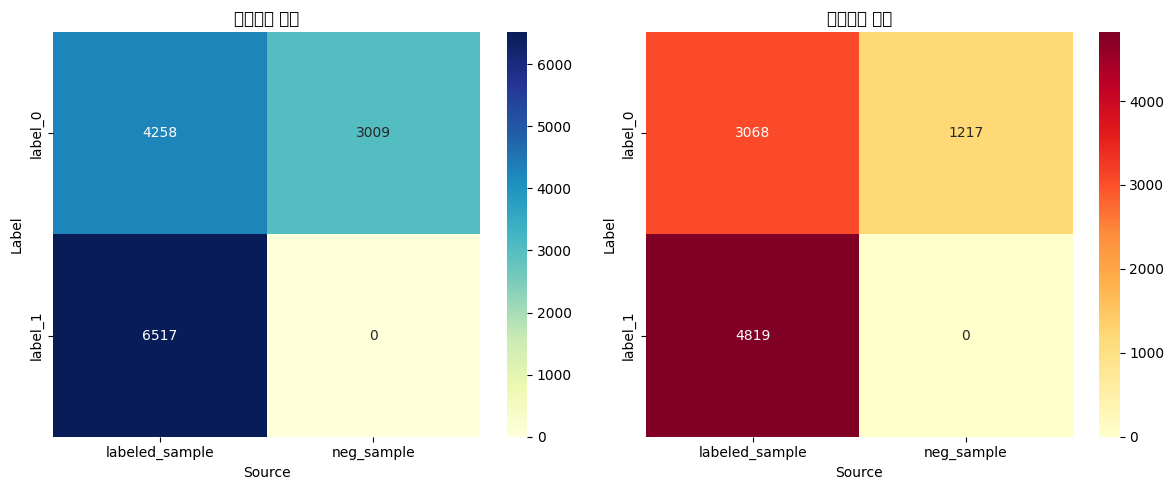

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 读取原始和去冗余后的数据
df_before = pd.read_csv("sequence_metadata.csv")
df_after = pd.read_csv("final_deduplicated_dataset.csv")

# 构建一个统计矩阵用于热图：index 是 label（0/1），columns 是 source（labeled_sample/neg_sample）
def get_heatmap_data(df):
    matrix = pd.DataFrame(
        np.zeros((2, 2), dtype=int),
        index=["label_0", "label_1"],
        columns=["labeled_sample", "neg_sample"]
    )
    for label in [0, 1]:
        for source in ["labeled_sample", "neg_sample"]:
            count = len(df[(df["label"] == label) & (df["source"] == source)])
            matrix.loc[f"label_{label}", source] = count
    return matrix

matrix_before = get_heatmap_data(df_before)
matrix_after = get_heatmap_data(df_after)

# 绘图：热图对比去冗余前后
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(matrix_before, annot=True, fmt="d", cmap="YlGnBu", ax=axes[0])
axes[0].set_title("去冗余前 热图")
axes[0].set_xlabel("Source")
axes[0].set_ylabel("Label")

sns.heatmap(matrix_after, annot=True, fmt="d", cmap="YlOrRd", ax=axes[1])
axes[1].set_title("去冗余后 热图")
axes[1].set_xlabel("Source")
axes[1].set_ylabel("Label")

plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 21435 (\N{CJK UNIFIED IDEOGRAPH-53BB}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 20887 (\N{CJK UNIFIED IDEOGRAPH-5197}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 20313 (\N{CJK UNIFIED IDEOGRAPH-4F59}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 20284 (\N{CJK UNIFIED IDEOGRAPH-4F3C}) missing from fon

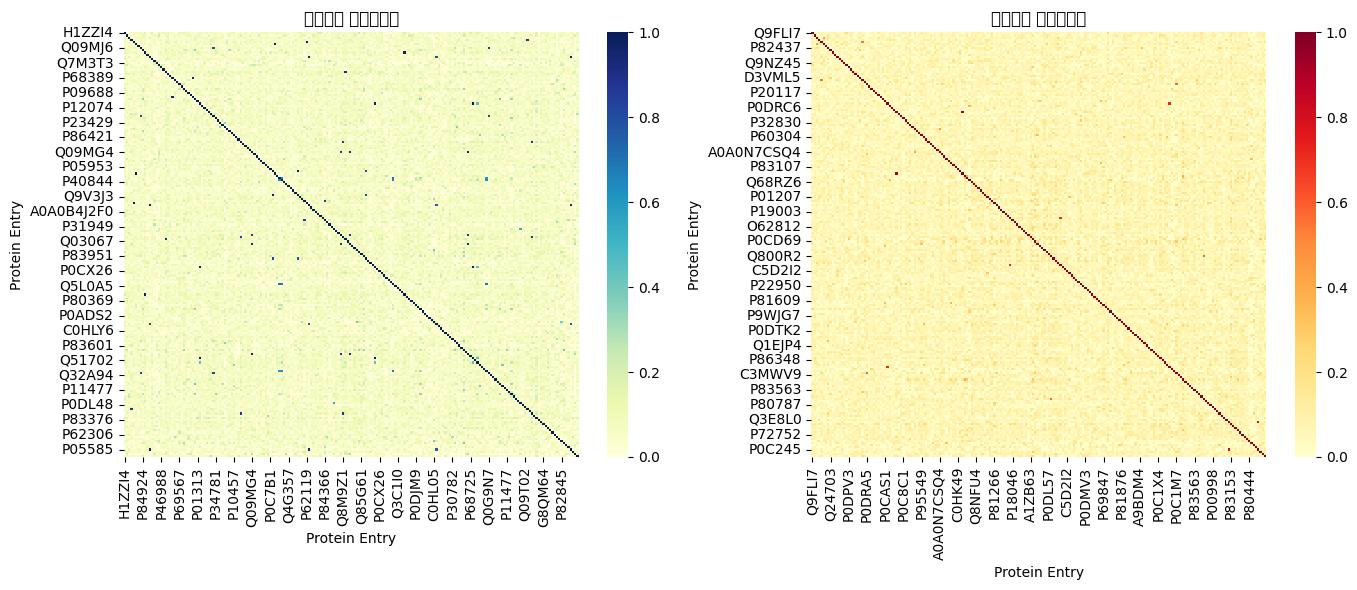

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 重新读取原始文件（去冗余前）
df_before = pd.read_csv("sequence_metadata.csv")

# 读取代表序列 FASTA 中的 IDs（去冗余后）
rep_ids = []
with open("rep_sequences.fasta") as f:
    for line in f:
        if line.startswith(">"):
            rep_ids.append(line.strip().replace(">", ""))

# 构建去冗余后的 DataFrame
df_after = df_before[df_before["Entry"].isin(rep_ids)].reset_index(drop=True)

# 定义 identity 计算函数
def calc_identity(seq1, seq2):
    if len(seq1) != len(seq2):
        min_len = min(len(seq1), len(seq2))
        seq1, seq2 = seq1[:min_len], seq2[:min_len]
    matches = sum(a == b for a, b in zip(seq1, seq2))
    return matches / len(seq1) if seq1 else 0.0

# 限制最大样本数用于绘图（避免内存过大）
MAX_SAMPLES = 200
df_before_sample = df_before.sample(n=MAX_SAMPLES, random_state=42).reset_index(drop=True)
df_after_sample = df_after.sample(n=MAX_SAMPLES, random_state=42).reset_index(drop=True)

# 构建相似度矩阵函数
def compute_similarity_matrix(df):
    n = len(df)
    matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(i, n):
            sim = calc_identity(df.loc[i, "Sequence"], df.loc[j, "Sequence"])
            matrix[i, j] = sim
            matrix[j, i] = sim
    return pd.DataFrame(matrix, index=df["Entry"], columns=df["Entry"])

sim_before = compute_similarity_matrix(df_before_sample)
sim_after = compute_similarity_matrix(df_after_sample)

# 绘图：相似度热图对比
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(sim_before, cmap="YlGnBu", ax=axes[0])
axes[0].set_title("去冗余前 相似度热图")
axes[0].set_xlabel("Protein Entry")
axes[0].set_ylabel("Protein Entry")

sns.heatmap(sim_after, cmap="YlOrRd", ax=axes[1])
axes[1].set_title("去冗余后 相似度热图")
axes[1].set_xlabel("Protein Entry")
axes[1].set_ylabel("Protein Entry")

plt.tight_layout()
plt.show()
